### Load libraries

In [1]:
from pybaseball import statcast

import pandas as pd
import numpy as np
import polars as pl

import warnings
warnings.filterwarnings("ignore")

import lightgbm as lgb
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error

import optuna
optuna.logging.set_verbosity(optuna.logging.INFO)

import requests

import matplotlib.pyplot as plt
%matplotlib inline

from huggingface_hub import HfApi

In [2]:
# collect Statcast data
# documentation: https://baseballsavant.mlb.com/csv-docs
start_date = '2020-03-01'
end_date = '2025-10-31'

raw_data = statcast(start_date, end_date)
print(raw_data.shape)

This is a large query, it may take a moment to complete


  0%|                                                                                         | 0/1312 [00:00<?, ?it/s]

Skipping offseason dates
Skipping offseason dates
Skipping offseason dates
Skipping offseason dates
Skipping offseason dates
Skipping offseason dates


100%|██████████████████████████████████████████████████████████████████████████████| 1312/1312 [06:46<00:00,  3.23it/s]


(4126175, 118)


In [137]:
df = raw_data.copy().reset_index(drop=True)
# re-format names to readable format
split_names = df["player_name"].fillna("").str.split(",", n=1)
df["PlayerName"] = np.where(
    split_names.str.len() == 2,
    split_names.str[1].str.strip() + " " + split_names.str[0].str.strip(),
    df["player_name"]
)

In [138]:
## Define a dictionary to group outcomes together for expected run values
des_dict = {'ball':'ball',
'hit_into_play':'hit_into_play',
'called_strike':'called_strike',
'foul':'foul',
'swinging_strike':'swinging_strike',
'blocked_ball':'ball',
'swinging_strike_blocked':'swinging_strike',
'foul_tip':'swinging_strike',
'foul_bunt':'foul',
'hit_by_pitch':'hit_by_pitch',
'pitchout':'ball',
'missed_bunt':'swinging_strike',
'bunt_foul_tip':'swinging_strike',
'foul_pitchout':'foul',}

## Define a dictionary to group events together for expected run values
ev_dict = {'game_advisory':np.nan,
 'single':'single',
 'walk':'walk',
 np.nan:np.nan,
 'strikeout':'strikeout',
 'field_out':'field_out',
 'force_out':'field_out',
 'double':'double',
 'hit_by_pitch':'hit_by_pitch',
 'home_run':'home_run',
 'grounded_into_double_play':'field_out',
 'fielders_choice_out':'field_out',
 'fielders_choice':'field_out',
 'field_error':np.nan,
 'double_play':'field_out',
 'sac_fly':'field_out',
 'strikeout_double_play':np.nan,
 'triple':'triple',
 'caught_stealing_2b':np.nan,
 'sac_bunt':'field_out',
 'catcher_interf':np.nan,
 'caught_stealing_3b':np.nan,
 'sac_fly_double_play':'field_out',
 'triple_play':'field_out',
 'other_out':'field_out',
 'pickoff_3b':np.nan,
 'caught_stealing_home':np.nan,
 'pickoff_1b':np.nan,
 'pickoff_2b':np.nan,
 'wild_pitch':'wild_pitch',
 'stolen_base_2b':np.nan,
 'pickoff_caught_stealing_3b':np.nan,
 'pickoff_caught_stealing_2b':np.nan,
 'sac_bunt_double_play':np.nan,
 'passed_ball':np.nan,
 'pickoff_caught_stealing_home':np.nan,}

In [139]:
# Define a function which applies relevant transformations
# Code derived from Thomas Nestico

def clean_for_xrv(df, val_year):
    df = df[(df.balls != 4) & (df.strikes != 3)].copy()

    df["des_new"] = df["description"].map(des_dict)
    df["des_new"] = np.where((df["des_new"] == "ball") & (df["balls"] == 3), "walk", df["des_new"])
    df["des_new"] = np.where(
        (df["des_new"].isin(["called_strike", "swinging_strike"])) & (df["strikes"] == 2),
        "strikeout",
        df["des_new"],
    )
    df["ev_new"] = df.loc[df["des_new"] == "hit_into_play", "events"].map(ev_dict)
    df.loc[df["des_new"] == "hit_into_play", "des_new"] = df.loc[df["des_new"] == "hit_into_play", "ev_new"]
    df = df.dropna(subset=["des_new"])

    train_mask = (df["game_year"].to_numpy() < val_year)

    des_values = (
        df.loc[train_mask]
          .groupby(["des_new", "strikes", "balls"])["delta_run_exp"]
          .mean()
          .reset_index(name="delta_run_exp_mean")
    )

    df = df.merge(des_values, on=["des_new", "strikes", "balls"], how="left")

    global_mean = df.loc[train_mask, "delta_run_exp"].mean()
    df["delta_run_exp_mean"] = df["delta_run_exp_mean"].fillna(global_mean)

    return df.dropna(subset=["pitch_type"])

In [140]:
def add_primary_pitch_deltas(
    df,
    primary_choices=("FF", "SI", "FC"),
    *,
    pitcher_col="pitcher",
    year_col="game_year",
    pitch_type_col="pitch_type",
    speed_col="release_speed",
    pfx_x_col="pfx_x",
    pfx_z_col="pfx_z",
):
    """
    Adds primary pitch baseline per pitcher-season and deltas vs that baseline.

    Primary pitch definition:
      - among `primary_choices`, pick the most-used pitch type for a given pitcher-season
      - tiebreaker: higher avg speed

    Fallback if pitcher-season throws none of `primary_choices`:
      - use fastest pitch (by avg speed) for that pitcher-season

    Returns a pandas DataFrame with:
      - avg_primary_speed, avg_primary_pfx_x, avg_primary_pfx_z
      - primary_delta_release_speed, primary_delta_pfx_x, primary_delta_pfx_z
    """

    pdf = df.copy()
    pl_df = pl.from_pandas(pdf)

    group_keys = [pitcher_col, year_col, pitch_type_col]

    # aggregate pitch-type means and counts per pitcher-season
    agg = (
        pl_df.group_by(group_keys)
        .agg(
            pl.len().alias("pt_count"),
            pl.col(speed_col).mean().alias("pt_avg_speed"),
            pl.col(pfx_z_col).mean().alias("pt_avg_pfx_z"),
            pl.col(pfx_x_col).mean().alias("pt_avg_pfx_x"),
        )
    )

    # candidate primary among chosen pitch types
    primary_candidates = (
        agg.filter(pl.col(pitch_type_col).is_in(list(primary_choices)))
        .sort(
            by=[pitcher_col, year_col, "pt_count", "pt_avg_speed"],
            descending=[False, False, True, True],
        )
        .unique(subset=[pitcher_col, year_col], keep="first")
        .select(
            pitcher_col,
            year_col,
            pl.col("pt_avg_speed").alias("avg_primary_speed"),
            pl.col("pt_avg_pfx_z").alias("avg_primary_pfx_z"),
            pl.col("pt_avg_pfx_x").alias("avg_primary_pfx_x"),
        )
    )

    # fallback: fastest pitch type for that pitcher-season (if no primary_choices)
    fastest_fallback = (
        agg.sort(
            by=[pitcher_col, year_col, "pt_avg_speed"],
            descending=[False, False, True],
        )
        .unique(subset=[pitcher_col, year_col], keep="first")
        .select(
            pitcher_col,
            year_col,
            pl.col("pt_avg_speed").alias("fb_primary_speed"),
            pl.col("pt_avg_pfx_z").alias("fb_primary_pfx_z"),
            pl.col("pt_avg_pfx_x").alias("fb_primary_pfx_x"),
        )
    )

    # join both baselines to every pitch row
    pl_df = (
        pl_df.join(primary_candidates, on=[pitcher_col, year_col], how="left")
             .join(fastest_fallback, on=[pitcher_col, year_col], how="left")
             .with_columns(
                 pl.when(pl.col("avg_primary_speed").is_null())
                   .then(pl.col("fb_primary_speed"))
                   .otherwise(pl.col("avg_primary_speed"))
                   .alias("avg_primary_speed"),
                 pl.when(pl.col("avg_primary_pfx_z").is_null())
                   .then(pl.col("fb_primary_pfx_z"))
                   .otherwise(pl.col("avg_primary_pfx_z"))
                   .alias("avg_primary_pfx_z"),
                 pl.when(pl.col("avg_primary_pfx_x").is_null())
                   .then(pl.col("fb_primary_pfx_x"))
                   .otherwise(pl.col("avg_primary_pfx_x"))
                   .alias("avg_primary_pfx_x"),
             )
             .drop(["fb_primary_speed", "fb_primary_pfx_z", "fb_primary_pfx_x"])
    )

    # deltas vs baseline
    pl_df = pl_df.with_columns(
        (pl.col(speed_col) - pl.col("avg_primary_speed")).alias("primary_delta_release_speed"),
        (pl.col(pfx_z_col) - pl.col("avg_primary_pfx_z")).alias("primary_delta_pfx_z"),
        (pl.col(pfx_x_col) - pl.col("avg_primary_pfx_x")).alias("primary_delta_pfx_x"),
    )

    pl_df = pl_df.with_columns(pl.col(year_col).cast(pl.Int64))

    return pl_df.to_pandas()

In [141]:
def clean_data(df, val_year):
    
    df = df[df.game_type == 'R'].copy()  # regular season only

    # required columns
    must_have_cols = [
        'p_throws', 'pfx_x', 'pfx_z', 'release_speed', 'spin_axis',
        'release_spin_rate', 'release_extension',
        'release_pos_x', 'release_pos_z', 'arm_angle', 'p_throws'
    ]
    df = df.dropna(subset=must_have_cols)

    # remove unidentified pitches
    df = df[df.pitch_name != 'Other']

    # remove bunts
    bunt_plays = ['bunt_foul_tip', 'foul_bunt', 'missed_bunt']
    df = df[~df.description.isin(bunt_plays)]

    # remove clearly bad extensions
    df = df[df.release_extension <= 10]

    # rename batter stance
    df = df.rename(columns={'stand': 'batter_handedness'})

    # drop deprecated columns
    deprecated_columns = [c for c in df.columns if 'deprecated' in c]
    df = df.drop(columns=deprecated_columns)

    # filter rare pitch types globally
    vc = df['pitch_type'].value_counts()
    included_pitches = vc[vc >= 5000].index
    df = df[df.pitch_type.isin(included_pitches)]

    # handedness feature
    df['is_lefty'] = (df['p_throws'] == 'L').astype(int)

    # convert movement to inches
    df['pfx_x'] = df['pfx_x'] * 12.0
    df['pfx_z'] = df['pfx_z'] * 12.0
    
    # same_side matchup feature — captures platoon split context
    df['same_side'] = (df['p_throws'] == df['batter_handedness']).astype(int)

    # mirror pfx_x for model so arm-side is always positive regardless of handedness
    df['pfx_x_mirrored'] = df['pfx_x'] * np.where(df['p_throws'] == 'L', -1, 1)

    eps = 1e-9
    train_mask = df['game_year'] < val_year  # avoid leakage

    # -------------------------
    # spin efficiency
    # accounts for flight distance via extension; transverse spin back-calculated from observed movement
    # -------------------------
    SEAM_CONSTANT = 0.01267

    df['total_movement'] = np.sqrt(df['pfx_x']**2 + df['pfx_z']**2)
    df['flight_distance'] = 60.5 - df['release_extension']

    df['transverse_spin_est'] = (
        df['total_movement'] * df['release_speed']
        / (SEAM_CONSTANT * df['flight_distance'] + eps)
    )

    df['spin_efficiency'] = (
        df['transverse_spin_est'] / (df['release_spin_rate'] + eps)
    ).clip(0, 1)

    # -------------------------
    # spin axis features
    # -------------------------
    df['spin_axis'] = pd.to_numeric(df['spin_axis'], errors='coerce')
    df = df.dropna(subset=['spin_axis'])

    df['spin_axis_rad'] = np.deg2rad(df['spin_axis'])
    df['spin_axis_x'] = np.cos(df['spin_axis_rad'])
    df['spin_axis_y'] = np.sin(df['spin_axis_rad'])

    # -------------------------
    # seam-shifted wake features
    # Magnus magnitude = spin_efficiency fraction of observed movement
    # direction derived from spin axis
    # SSW = residual after removing Magnus estimate
    # convention: HB_obs > 0 -> 3B side, HB_obs < 0 -> 1B side
    # -------------------------
    df['HB_obs']  = -df['pfx_x']
    df['iVB_obs'] =  df['pfx_z']

    df['movement_mag_obs'] = np.sqrt(
        df['HB_obs']**2 + df['iVB_obs']**2
    )

    # Magnus magnitude = spin efficiency fraction of total movement
    df['magnus_mag_est'] = df['spin_efficiency'] * df['movement_mag_obs']

    # Magnus direction from spin axis
    theta = np.deg2rad(df['spin_axis'] - 90)
    df['HB_magnus_est']  = -df['magnus_mag_est'] * np.cos(theta)
    df['iVB_magnus_est'] =  df['magnus_mag_est'] * np.sin(theta)

    # SSW = residual after removing Magnus
    df['ssw_x'] = df['HB_obs'] - df['HB_magnus_est']
    df['ssw_z'] = df['iVB_obs'] - df['iVB_magnus_est']
    df['ssw_in'] = np.sqrt(df['ssw_x']**2 + df['ssw_z']**2)

    # Pitch usage filtering
    counts = df.groupby(['pitcher', 'game_year', 'pitch_type']).size().rename('count')
    totals = df.groupby(['pitcher', 'game_year']).size().rename('total')

    pitch_frequencies = (
        counts.to_frame()
              .join(totals, on=['pitcher', 'game_year'])
    )
    pitch_frequencies['usage'] = pitch_frequencies['count'] / pitch_frequencies['total']
    pitch_frequencies = pitch_frequencies.reset_index()

    pitch_frequencies = pitch_frequencies[
        (pitch_frequencies['count'] >= 10) &
        (pitch_frequencies['usage'] > 0.01)
    ]

    df = df.merge(
        pitch_frequencies[['pitcher', 'game_year', 'pitch_type']],
        on=['pitcher', 'game_year', 'pitch_type'],
        how='inner'
    )

    return df, pitch_frequencies

In [142]:
year_col = "game_year"
pitch_type_col = "pitch_type"
target = "delta_run_exp_mean"

all_years = sorted(df[year_col].dropna().astype(int).unique())
if len(all_years) < 3:
    raise ValueError(f"Need >=3 distinct years for train/tune/report. Found: {all_years}")

report_year = int(all_years[-1])
val_year    = int(all_years[-2])          # tune / early-stop year
train_years = [int(y) for y in all_years[:-2]]

print(f"Train years: {train_years}")
print(f"Tune year:   {val_year}")
print(f"Report year: {report_year}")

Train years: [2020, 2021, 2022, 2023]
Tune year:   2024
Report year: 2025


In [143]:
df = clean_for_xrv(df, val_year)

In [144]:
# Clean + engineer features
primary_choices = ['FF', 'SI', 'FC']
df, pitch_frequencies = clean_data(df, val_year)
df = add_primary_pitch_deltas(df, primary_choices=primary_choices)

In [145]:
ID_COLS = ["pitcher", "PlayerName"]

numeric_features = [
    'pfx_x_mirrored',
    'pfx_z',
    'release_speed', 'release_spin_rate', 'release_extension',
    'release_pos_x', 'release_pos_z',
    'spin_axis_x', 'spin_axis_y', 'spin_efficiency',
    'ssw_x', 'ssw_z', 'ssw_in',
    'same_side',
    'primary_delta_release_speed',
    'primary_delta_pfx_x', 'primary_delta_pfx_z',
]

categorical_features = [pitch_type_col]

model_features = numeric_features + categorical_features

KEEP_COLS = (
    ID_COLS
    + [year_col, target]
    + model_features
    + [
        "pfx_x",
        "spin_axis",
        "pitch_name",
        "p_throws",
        "batter_handedness",
        "arm_angle",
        "HB_obs",
        "iVB_obs",
        "movement_mag_obs",
        "magnus_mag_est",
        "HB_magnus_est",
        "iVB_magnus_est",
    ]
)

KEEP_COLS = list(dict.fromkeys(KEEP_COLS))

df_current = df[KEEP_COLS].copy()

In [146]:
def tune_refit_predict(
    df_all,
    tune_year,
    report_year,
    train_years,
    *,
    year_col="game_year",
    pitch_type_col="pitch_type",
    target_col=target,
    model_features=model_features,
    n_trials=75,
):

    n_estimators_max = 5000
    early_stopping_rounds = 100
    seed = 162

    # 1) Tune on tune_year
    df_train = df_all[df_all[year_col].isin(train_years)].copy()
    df_tune  = df_all[df_all[year_col] == tune_year].copy()

    X_train = df_train[model_features].copy()
    y_train = df_train[target_col].copy()
    X_tune  = df_tune[model_features].copy()
    y_tune  = df_tune[target_col].copy()

    X_train[pitch_type_col] = X_train[pitch_type_col].astype("category")
    X_tune[pitch_type_col]  = X_tune[pitch_type_col].astype("category")

    def objective(trial):
        params = {
            "random_state": seed,
            "metric": "rmse",
            "n_estimators": n_estimators_max,
            "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.10, log=True),
            "max_depth": trial.suggest_int("max_depth", 3, 10),
            "num_leaves": trial.suggest_int("num_leaves", 16, 256),
            "min_child_samples": trial.suggest_int("min_child_samples", 10, 200, log=True),
            "subsample": trial.suggest_float("subsample", 0.5, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 25.0, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 25.0, log=True),
            "force_row_wise": True,
            "verbosity": -1,
        }

        model = LGBMRegressor(**params)
        model.fit(
            X_train, y_train,
            eval_set=[(X_tune, y_tune)],
            eval_metric="rmse",
            categorical_feature=[pitch_type_col],
            callbacks=[lgb.early_stopping(early_stopping_rounds, verbose=False)],
        )
        preds = model.predict(X_tune)
        return mean_squared_error(y_tune, preds, squared=False)

    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=n_trials)

    # capture best params
    best_params = study.best_params.copy()
    best_params.update({
        "random_state": seed,
        "metric": "rmse",
        "force_row_wise": True,
        "verbosity": -1,
    })

    # fit a probe model once more to get best_iteration_
    probe_params = best_params.copy()
    probe_params["n_estimators"] = n_estimators_max

    probe_model = LGBMRegressor(**probe_params)
    probe_model.fit(
        X_train, y_train,
        eval_set=[(X_tune, y_tune)],
        eval_metric="rmse",
        categorical_feature=[pitch_type_col],
        callbacks=[lgb.early_stopping(early_stopping_rounds, verbose=False)],
    )

    best_n_estimators = int(getattr(probe_model, "best_iteration_", None) or n_estimators_max)
    best_params["n_estimators"] = best_n_estimators

    tune_preds = probe_model.predict(X_tune)
    tune_rmse = mean_squared_error(y_tune, tune_preds, squared=False)

    # 2) Refit on (train_years + tune_year), params fixed
    refit_years = list(train_years) + [tune_year]
    df_refit = df_all[df_all[year_col].isin(refit_years)].copy()

    X_refit = df_refit[model_features].copy()
    y_refit = df_refit[target_col].copy()

    X_refit[pitch_type_col] = X_refit[pitch_type_col].astype("category")

    final_model = LGBMRegressor(**best_params)
    final_model.fit(
        X_refit, y_refit,
        categorical_feature=[pitch_type_col],
    )

    # 3) Predict/report on report_year
    df_report = df_all[df_all[year_col] == report_year].copy()
    X_report  = df_report[model_features].copy()
    X_report[pitch_type_col] = X_report[pitch_type_col].astype("category")

    df_report["pred_target_oos"] = final_model.predict(X_report)

    report_rmse = None
    if target_col in df_report.columns and df_report[target_col].notna().any():
        report_rmse = mean_squared_error(
            df_report[target_col],
            df_report["pred_target_oos"],
            squared=False,
        )

    feature_importance = pd.DataFrame({
        "feature": model_features,
        "importance": final_model.feature_importances_,
    }).sort_values("importance", ascending=False).reset_index(drop=True)

    result = {
        "report_year": report_year,
        "tune_year": tune_year,
        "train_years": train_years,
        "refit_years": refit_years,

        "study": study,
        "best_params": best_params.copy(),
        "best_n_estimators": best_n_estimators,

        "probe_model": probe_model,
        "final_model": final_model,

        "df_train": df_train,
        "df_tune": df_tune,
        "df_refit": df_refit,
        "df_report": df_report,

        "X_train": X_train,
        "y_train": y_train,
        "X_tune": X_tune,
        "y_tune": y_tune,
        "X_refit": X_refit,
        "y_refit": y_refit,
        "X_report": X_report,

        "tune_preds": tune_preds,
        "tune_rmse": tune_rmse,
        "report_rmse": report_rmse,

        "feature_importance": feature_importance,
    }

    return result

In [147]:
def rolling_oos_predictions(
    df_all,
    *,
    year_col="game_year",
    min_train_years=2,
    n_trials=75,
):
    years = sorted(df_all[year_col].dropna().astype(int).unique())

    all_preds = []
    results_by_year = {}
    models_by_year = {}
    summaries = []

    # Need at least [train years] + [tune year] + [report year]
    for i in range(min_train_years + 1, len(years)):
        report_year = int(years[i])
        tune_year = int(years[i - 1])
        train_years = [int(y) for y in years[:i - 1]]

        print(f"\n=== report_year={report_year} | tune_year={tune_year} | train_years={train_years} ===")

        result = tune_refit_predict(
            df_all,
            tune_year=tune_year,
            report_year=report_year,
            train_years=train_years,
            n_trials=n_trials,
        )

        print(
            f"Best RMSE: {result['study'].best_value:.6f} "
            f"| best_n_estimators: {result['best_n_estimators']}"
        )

        results_by_year[report_year] = result
        models_by_year[report_year] = result["final_model"]
        all_preds.append(result["df_report"])

        summaries.append({
            "report_year": result["report_year"],
            "tune_year": result["tune_year"],
            "train_years": result["train_years"],
            "n_train_rows": len(result["df_train"]),
            "n_tune_rows": len(result["df_tune"]),
            "n_refit_rows": len(result["df_refit"]),
            "n_report_rows": len(result["df_report"]),
            "best_value_rmse": result["study"].best_value,
            "tune_rmse": result["tune_rmse"],
            "report_rmse": result["report_rmse"],
            "best_n_estimators": result["best_n_estimators"],
            "best_params": result["best_params"],
        })

    if not all_preds:
        raise ValueError("No rolling predictions were created. Check available years and min_train_years.")

    predictions = pd.concat(all_preds, ignore_index=True)
    summary_df = pd.DataFrame(summaries)

    last_report_year = max(results_by_year.keys())

    return {
        "predictions": predictions,
        "summary": summary_df,
        "results_by_year": results_by_year,
        "models_by_year": models_by_year,
        "last_model": results_by_year[last_report_year]["final_model"],
        "last_result": results_by_year[last_report_year],
        "last_report_year": last_report_year,
    }

In [148]:
rolling_results = rolling_oos_predictions(df_current)

df_pred_all = rolling_results["predictions"]
summary_df = rolling_results["summary"]
last_model = rolling_results["last_model"]
last_result = rolling_results["last_result"]
models_by_year = rolling_results["models_by_year"]
results_by_year = rolling_results["results_by_year"]


=== report_year=2023 | tune_year=2022 | train_years=[2020, 2021] ===


[I 2026-03-16 14:21:18,274] A new study created in memory with name: no-name-dafbc001-f247-4f54-82dc-11e3b0006171
[I 2026-03-16 14:21:27,047] Trial 0 finished with value: 0.21461746466464926 and parameters: {'learning_rate': 0.011026165419063129, 'max_depth': 5, 'num_leaves': 119, 'min_child_samples': 19, 'subsample': 0.621340827039747, 'colsample_bytree': 0.8964479836090595, 'reg_alpha': 0.1486287288317992, 'reg_lambda': 0.0017988482422206984}. Best is trial 0 with value: 0.21461746466464926.
[I 2026-03-16 14:21:32,155] Trial 1 finished with value: 0.2146206176288185 and parameters: {'learning_rate': 0.03684761056370347, 'max_depth': 10, 'num_leaves': 215, 'min_child_samples': 93, 'subsample': 0.9685093890491696, 'colsample_bytree': 0.7494223227373749, 'reg_alpha': 0.01046615053186389, 'reg_lambda': 0.0040742379442069866}. Best is trial 0 with value: 0.21461746466464926.
[I 2026-03-16 14:21:46,308] Trial 2 finished with value: 0.21461383206939377 and parameters: {'learning_rate': 0.00

[I 2026-03-16 14:24:18,885] Trial 21 finished with value: 0.21460616544428787 and parameters: {'learning_rate': 0.02119001498763777, 'max_depth': 8, 'num_leaves': 100, 'min_child_samples': 54, 'subsample': 0.8983083567329269, 'colsample_bytree': 0.7008120532549826, 'reg_alpha': 2.3635380606283753, 'reg_lambda': 0.6092570289283165}. Best is trial 12 with value: 0.21460144371480588.
[I 2026-03-16 14:24:25,897] Trial 22 finished with value: 0.21460142445425243 and parameters: {'learning_rate': 0.01811913405046705, 'max_depth': 9, 'num_leaves': 70, 'min_child_samples': 71, 'subsample': 0.8671806518768223, 'colsample_bytree': 0.5661834108287663, 'reg_alpha': 7.673460110688832, 'reg_lambda': 1.3269690292635195}. Best is trial 22 with value: 0.21460142445425243.
[I 2026-03-16 14:24:33,421] Trial 23 finished with value: 0.21460373486278442 and parameters: {'learning_rate': 0.027354543408451105, 'max_depth': 9, 'num_leaves': 39, 'min_child_samples': 156, 'subsample': 0.9355133539683943, 'colsam

[I 2026-03-16 14:27:28,662] Trial 42 finished with value: 0.2145995477538904 and parameters: {'learning_rate': 0.0102861306461994, 'max_depth': 9, 'num_leaves': 106, 'min_child_samples': 82, 'subsample': 0.7875094611615281, 'colsample_bytree': 0.7307583732659703, 'reg_alpha': 11.82491380460047, 'reg_lambda': 0.07964554427464582}. Best is trial 42 with value: 0.2145995477538904.
[I 2026-03-16 14:27:44,155] Trial 43 finished with value: 0.21460037760473072 and parameters: {'learning_rate': 0.009570738163648881, 'max_depth': 9, 'num_leaves': 110, 'min_child_samples': 113, 'subsample': 0.7913820342832252, 'colsample_bytree': 0.8031703926784306, 'reg_alpha': 13.0596565818499, 'reg_lambda': 0.0754629635781832}. Best is trial 42 with value: 0.2145995477538904.
[I 2026-03-16 14:28:02,122] Trial 44 finished with value: 0.21460086728112965 and parameters: {'learning_rate': 0.005804683033516909, 'max_depth': 10, 'num_leaves': 110, 'min_child_samples': 115, 'subsample': 0.7774086120751634, 'colsam

[I 2026-03-16 15:25:18,359] Trial 63 finished with value: 0.21460512143912927 and parameters: {'learning_rate': 0.01132114674117748, 'max_depth': 5, 'num_leaves': 91, 'min_child_samples': 78, 'subsample': 0.7449367237096561, 'colsample_bytree': 0.8568036498926558, 'reg_alpha': 17.28014503450931, 'reg_lambda': 0.001407983654282935}. Best is trial 62 with value: 0.21459782496046464.
[I 2026-03-16 15:25:30,086] Trial 64 finished with value: 0.2145996432740958 and parameters: {'learning_rate': 0.010280560187028265, 'max_depth': 10, 'num_leaves': 80, 'min_child_samples': 126, 'subsample': 0.7712696381795298, 'colsample_bytree': 0.7946358997945541, 'reg_alpha': 7.853741695751351, 'reg_lambda': 0.1304571872553153}. Best is trial 62 with value: 0.21459782496046464.
[I 2026-03-16 15:25:44,378] Trial 65 finished with value: 0.2146026511102178 and parameters: {'learning_rate': 0.0073740062580189255, 'max_depth': 10, 'num_leaves': 133, 'min_child_samples': 147, 'subsample': 0.7641316546031338, 'co

...

[I 2026-03-16 16:19:18,268] A new study created in memory with name: no-name-721683e8-b7e3-4947-b9a8-9e9d0642651a
[I 2026-03-16 16:20:10,135] Trial 0 finished with value: 0.21635873728256472 and parameters: {'learning_rate': 0.008441417750146526, 'max_depth': 4, 'num_leaves': 91, 'min_child_samples': 17, 'subsample': 0.9334025757897322, 'colsample_bytree': 0.660809932857191, 'reg_alpha': 1.0215389477786374, 'reg_lambda': 0.06632681427055058}. Best is trial 0 with value: 0.21635873728256472.
[I 2026-03-16 16:20:46,342] Trial 1 finished with value: 0.2163624412082952 and parameters: {'learning_rate': 0.02363954819246042, 'max_depth': 3, 'num_leaves': 124, 'min_child_samples': 28, 'subsample': 0.5504258977137786, 'colsample_bytree': 0.6512281833317259, 'reg_alpha': 0.011622127657803037, 'reg_lambda': 0.7003388371492398}. Best is trial 0 with value: 0.21635873728256472.
[I 2026-03-16 16:21:32,573] Trial 2 finished with value: 0.21636183654502347 and parameters: {'learning_rate': 0.01461789

[I 2026-03-16 16:30:20,819] Trial 21 finished with value: 0.2163498166256133 and parameters: {'learning_rate': 0.018178961467674403, 'max_depth': 7, 'num_leaves': 93, 'min_child_samples': 37, 'subsample': 0.6642369980247698, 'colsample_bytree': 0.7206456462706452, 'reg_alpha': 7.438096059825642, 'reg_lambda': 24.18673225195051}. Best is trial 19 with value: 0.2163478189060972.
[I 2026-03-16 16:30:44,247] Trial 22 finished with value: 0.21634868830963008 and parameters: {'learning_rate': 0.019011917777243346, 'max_depth': 7, 'num_leaves': 90, 'min_child_samples': 36, 'subsample': 0.6587674242605926, 'colsample_bytree': 0.7598721520126434, 'reg_alpha': 4.904913132146574, 'reg_lambda': 23.292378799274843}. Best is trial 19 with value: 0.2163478189060972.
[I 2026-03-16 16:31:02,917] Trial 23 finished with value: 0.21635095955777758 and parameters: {'learning_rate': 0.022680002041738787, 'max_depth': 7, 'num_leaves': 85, 'min_child_samples': 23, 'subsample': 0.6161022691107106, 'colsample_b

[I 2026-03-16 16:39:03,904] Trial 42 finished with value: 0.21634869364467998 and parameters: {'learning_rate': 0.020256105663066515, 'max_depth': 7, 'num_leaves': 96, 'min_child_samples': 44, 'subsample': 0.5434793161406454, 'colsample_bytree': 0.7627765113083861, 'reg_alpha': 23.449067292377844, 'reg_lambda': 0.2733287238794079}. Best is trial 19 with value: 0.2163478189060972.
[I 2026-03-16 16:39:42,210] Trial 43 finished with value: 0.21634944172951767 and parameters: {'learning_rate': 0.01655981209578182, 'max_depth': 8, 'num_leaves': 74, 'min_child_samples': 42, 'subsample': 0.6524808044771759, 'colsample_bytree': 0.7200374415854487, 'reg_alpha': 23.4659696093703, 'reg_lambda': 0.06683123250516612}. Best is trial 19 with value: 0.2163478189060972.
[I 2026-03-16 16:40:06,895] Trial 44 finished with value: 0.2163484040166385 and parameters: {'learning_rate': 0.019423823873066952, 'max_depth': 7, 'num_leaves': 101, 'min_child_samples': 48, 'subsample': 0.5429173379882436, 'colsample

[I 2026-03-16 16:49:21,226] Trial 63 finished with value: 0.21634794572691074 and parameters: {'learning_rate': 0.017751131054521002, 'max_depth': 8, 'num_leaves': 94, 'min_child_samples': 35, 'subsample': 0.5996634592735455, 'colsample_bytree': 0.7400355671784213, 'reg_alpha': 5.749308861491545, 'reg_lambda': 0.027850314998028213}. Best is trial 19 with value: 0.2163478189060972.
[I 2026-03-16 16:49:43,411] Trial 64 finished with value: 0.21634872649729325 and parameters: {'learning_rate': 0.01782341674897382, 'max_depth': 8, 'num_leaves': 90, 'min_child_samples': 34, 'subsample': 0.5994146128287846, 'colsample_bytree': 0.7306685104010368, 'reg_alpha': 5.9941498478564, 'reg_lambda': 0.005309372607485294}. Best is trial 19 with value: 0.2163478189060972.
[I 2026-03-16 16:50:06,264] Trial 65 finished with value: 0.21634830155517762 and parameters: {'learning_rate': 0.01549118934262321, 'max_depth': 8, 'num_leaves': 79, 'min_child_samples': 25, 'subsample': 0.5694651791885792, 'colsample

Best RMSE: 0.216348 | best_n_estimators: 541


In [149]:
stuff_sd = 10
eps = 1e-9

d = df_pred_all.copy()

# 1) Global Stuff+ — normalized within each year
# ensures 110 in 2022 means the same as 110 in 2025
mu_g = d.groupby(year_col)["pred_target_oos"].transform("mean")
sd_g = d.groupby(year_col)["pred_target_oos"].transform(
    lambda s: s.std(ddof=0)
)
z_g = (d["pred_target_oos"] - mu_g) / (sd_g + eps)

# Lower run value = better → higher Stuff+
d["Stuff+_global"] = 100 - stuff_sd * z_g

# 2) Pitch-type Stuff+ — normalized within each year and pitch type
pt_mu = d.groupby([year_col, pitch_type_col])["pred_target_oos"].transform("mean")
pt_sd = d.groupby([year_col, pitch_type_col])["pred_target_oos"].transform(
    lambda s: s.std(ddof=0)
)
z_pt = (d["pred_target_oos"] - pt_mu) / (pt_sd + eps)

d["Stuff+_pt"] = 100 - stuff_sd * z_pt

df_scored = d

In [150]:
arsenal = (
    df_scored.groupby(["pitcher", "game_year", "pitch_type"])
      .size()
      .rename("count")
      .reset_index()
)

totals = df_scored.groupby(["pitcher", "game_year"]).size().rename("total").reset_index()

arsenal = arsenal.merge(totals, on=["pitcher", "game_year"])
arsenal["usage"] = arsenal["count"] / arsenal["total"]

# Define a pitch to be part of a pitcher's arsenal if it is thrown 3% of the time and at least 100 times overall
min_frequency = 0.03
min_count = 100
arsenal["is_arsenal"] = (arsenal["count"] >= min_count) & (arsenal["usage"] >= min_frequency)

df_scored = df_scored.merge(
    arsenal[["pitcher", "game_year", "pitch_type", "is_arsenal"]],
    on=["pitcher", "game_year", "pitch_type"],
    how="left"
)

In [151]:
def fetch_fangraphs_pitching_stats(season: int, qual: int = 0, pageitems: int = 200000):
    
    base_url = "https://www.fangraphs.com/api/leaders/major-league/data"
    params = {
        "pos": "all",
        "stats": "pit",
        "lg": "all",
        "season": season,
        "season1": season,
        "ind": 1,
        "qual": qual,
        "type": 8,
        "month": 0,
        "pageitems": pageitems,
    }

    r = requests.get(base_url, params=params, timeout=30)
    r.raise_for_status()
    payload = r.json()

    df = pd.DataFrame(payload["data"])
    
    required = {"xMLBAMID", "IP"}
    missing = required - set(df.columns)
    if missing:
        raise KeyError(f"FanGraphs response missing columns: {missing}. Available: {sorted(df.columns)[:20]} ...")
    
    # ensure Season exists for filtering/merging consistency
    if "Season" not in df.columns:
        df["Season"] = season

    return df

In [152]:
# Fetch IP for all scored years, not just report_year
scored_years = sorted(rolling_results["results_by_year"].keys())

ip_all_years = []
for yr in scored_years:
    stats = fetch_fangraphs_pitching_stats(season=yr, qual=0)
    stats = stats[stats["Season"] == yr][["xMLBAMID", "IP", "Season"]].copy()
    ip_all_years.append(stats)

ip_all = pd.concat(ip_all_years, ignore_index=True).rename(columns={"Season": "game_year"})

# Merge IP into df_scored for all years
df_scored = df_scored.merge(
    ip_all,
    left_on=["pitcher", "game_year"],
    right_on=["xMLBAMID", "game_year"],
    how="left"
).drop(columns=["xMLBAMID"])

assert "IP" in df_scored.columns, (
    "IP missing from df_scored — FanGraphs merge did not run. "
    "Re-run this cell before proceeding to export."
)

In [153]:
def stuff_movement_heatmap(df, stuff_col="Stuff+_global"):
    
    fig, ax = plt.subplots(figsize=(7, 6))
    hb = ax.hexbin(
        df["pfx_x"],
        df["pfx_z"],
        C=df[stuff_col],
        reduce_C_function=np.mean,
        gridsize=30,
        cmap="RdBu_r",
        mincnt=1
    )
    
    x_lo, x_hi = df['pfx_x'].quantile([0.02, 0.98])
    y_lo, y_hi = df['pfx_z'].quantile([0.02, 0.98])

    ax.set_xlim(x_lo - 1.5, x_hi + 1.5)
    ax.set_ylim(y_lo - 1.5, y_hi + 1.5)

    ax.set_xlabel("Horizontal Break (inches)")
    ax.set_ylabel("Vertical Break (inches)")

    ax.axvline(0, linestyle="--", linewidth=1)
    ax.axhline(0, linestyle="--", linewidth=1)

    cb = fig.colorbar(hb, ax=ax)
    cb.set_label("Stuff+")

    plt.tight_layout()
    plt.show()

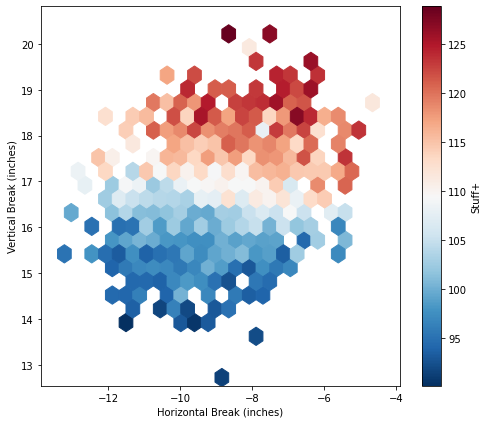

In [154]:
df_p = df_scored[df_scored['PlayerName'] == 'Jacob deGrom']
df_p = df_p[df_p.pitch_type == 'FF']

stuff_movement_heatmap(df_p, stuff_col="Stuff+_global")

In [155]:
pitcher_history = (
    df_scored
    .groupby(["game_year", "PlayerName", "pitch_type"], as_index=False)
    .agg(
        Pitches=("pitch_type", "size"),
        StuffPlus=("Stuff+_pt", "mean"),
        Velo=("release_speed", "mean"),
        HB=("HB_obs", "mean"),
        iVB=("pfx_z", "mean"),
        Spin=("release_spin_rate", "mean"),
        SpinAxis=("spin_axis", "mean"),
        SpinEff=("spin_efficiency", "mean"),
        SSW=("ssw_in", "mean"),
        ArmAngle=("arm_angle", "mean"),
        Extension=("release_extension", "mean"),
    )
)

# Add IP — one value per pitcher-season, broadcast across all pitch type rows
ip_per_pitcher = (
    df_scored[["PlayerName", "game_year", "IP"]]
    .dropna(subset=["IP"])
    .groupby(["PlayerName", "game_year"])["IP"]
    .max()
    .reset_index()
)

pitcher_history = pitcher_history.merge(
    ip_per_pitcher, on=["PlayerName", "game_year"], how="left"
)

min_year = min(rolling_results["results_by_year"].keys())
pitcher_history = pitcher_history[pitcher_history['game_year'] >= min_year].copy()
pitcher_history.to_parquet("pitcher_history.parquet", index=False)

In [156]:
# -----------------------------
# Define export columns
# -----------------------------

EXPORT_COLS = [
    "pitcher",
    "PlayerName",
    "IP",
    "game_year",
    "pitch_type",
    "pitch_name",

    "p_throws",
    "batter_handedness",
    "is_lefty",

    "release_speed",
    "release_spin_rate",
    "spin_axis",
    "spin_axis_x",
    "spin_axis_y",
    "spin_efficiency",

    "pfx_x",
    "pfx_z",
    "HB_obs",
    "iVB_obs",

    "HB_magnus_est",
    "iVB_magnus_est",

    "ssw_x",
    "ssw_z",
    "ssw_in",

    "release_pos_x",
    "release_pos_z",
    "release_extension",
    "flight_distance",
    "arm_angle",

    "primary_delta_release_speed",
    "primary_delta_pfx_x",
    "primary_delta_pfx_z",

    "pred_target_oos",
    "Stuff+_global",
    "Stuff+_pt",

    "is_arsenal",
]

# -----------------------------
# Shrink dataframe for export
# -----------------------------

EXPORT_COLS_PRESENT = [c for c in EXPORT_COLS if c in df_scored.columns]

df_export = df_scored[EXPORT_COLS_PRESENT].copy()

In [157]:
api = HfApi()
repo_id = "perld/stuff-plus-data"

for year, df_year in df_export.groupby("game_year"):
    filename = f"df_scored_{int(year)}.parquet"
    df_year.to_parquet(filename, index=False)
    api.upload_file(
        path_or_fileobj=filename,
        path_in_repo=filename,
        repo_id=repo_id,
        repo_type="dataset",
    )

api.upload_file(
    path_or_fileobj="pitcher_history.parquet",
    path_in_repo="pitcher_history.parquet",
    repo_id=repo_id,
    repo_type="dataset",
)

df_scored_2023.parquet:   0%|          | 0.00/68.5M [00:00<?, ?B/s]

df_scored_2024.parquet:   0%|          | 0.00/68.0M [00:00<?, ?B/s]

df_scored_2025.parquet:   0%|          | 0.00/68.4M [00:00<?, ?B/s]

pitcher_history.parquet:   0%|          | 0.00/961k [00:00<?, ?B/s]

CommitInfo(commit_url='https://huggingface.co/datasets/perld/stuff-plus-data/commit/fcc09e1cd9b0758c238a25286b61b9826477405e', commit_message='Upload pitcher_history.parquet with huggingface_hub', commit_description='', oid='fcc09e1cd9b0758c238a25286b61b9826477405e', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/perld/stuff-plus-data', endpoint='https://huggingface.co', repo_type='dataset', repo_id='perld/stuff-plus-data'), pr_revision=None, pr_num=None)

In [158]:
player_pitch = (
    df_scored[df_scored['is_arsenal']]
    .groupby(["pitcher", pitch_type_col])
    .agg(
        n_pitches=("pred_target_oos", "size"),
        StuffPlus_pt=("Stuff+_pt", "mean"),
        StuffPlus_global=("Stuff+_global", "mean"),
    )
    .reset_index()
)

pitcher_overall = (
    df_scored[df_scored['is_arsenal']]
    .groupby(["pitcher"])
    .agg(
        n_pitches=("pred_target_oos", "size"),
        StuffPlus_pt=("Stuff+_pt", "mean"),
        StuffPlus_global=("Stuff+_global", "mean"),
    )
    .reset_index()
)

In [159]:
# Wide tables: one row per pitcher, pitch types as columns
wide_pt = player_pitch.pivot(index="pitcher", columns=pitch_type_col, values="StuffPlus_pt")
wide_global = player_pitch.pivot(index="pitcher", columns=pitch_type_col, values="StuffPlus_global")

# Combine into one table with suffixes
wide = (
    wide_pt.add_suffix("_pt")
    .join(wide_global.add_suffix("_global"), how="outer")
    .reset_index()
)

# Add pitcher-level overall Stuff+
wide = wide.merge(pitcher_overall, on="pitcher", how="left")

# Rename for readability
wide = wide.rename(columns={
    "StuffPlus_pt": "Stuff+_pt_overall",
    "StuffPlus_global": "Stuff+_global_overall",
})

pitcher_to_name = (
    df_scored[["pitcher", "PlayerName"]]
    .dropna(subset=["pitcher", "PlayerName"])
    .drop_duplicates(subset=["pitcher"])
    .set_index("pitcher")["PlayerName"]
)

wide["PlayerName"] = wide["pitcher"].map(pitcher_to_name)
cols = ["PlayerName", "pitcher"] + [c for c in wide.columns if c not in ["PlayerName", "pitcher"]]
wide = wide[cols]

# Merge IP into wide for the qualified leaderboard (report year only)
ip_report = ip_all[ip_all["game_year"] == report_year][["xMLBAMID", "IP"]].copy()
wide = wide.merge(
    ip_report,
    left_on="pitcher",
    right_on="xMLBAMID",
    how="left"
).drop(columns=["xMLBAMID"])

In [160]:
qualified = wide[wide["IP"] >= 162].sort_values("Stuff+_global_overall", ascending=False)
qualified

,PlayerName,pitcher,CH_pt,CU_pt,FC_pt,FF_pt,FS_pt,KC_pt,SI_pt,SL_pt,...,FS_global,KC_global,SI_global,SL_global,ST_global,SV_global,n_pitches,Stuff+_pt_overall,Stuff+_global_overall,IP
137,Jacob deGrom,594798,111.118545,101.780254,NaN,108.635837,NaN,NaN,NaN,111.120896,...,NaN,NaN,NaN,110.977041,NaN,NaN,3010,109.522376,108.644754,172.2
497,Framber Valdez,664285,108.615724,117.757491,102.051849,NaN,NaN,NaN,102.549279,105.649095,...,NaN,NaN,103.521354,107.381224,NaN,NaN,8035,108.311426,106.337436,192.0
366,Dylan Cease,656302,NaN,NaN,NaN,106.899023,NaN,95.170820,100.593315,108.821240,...,NaN,97.039899,101.962283,109.363982,96.496285,NaN,9171,106.007819,105.870017,168.0
589,Tarik Skubal,669373,110.731335,94.536055,NaN,103.433358,NaN,NaN,105.157952,101.685571,...,NaN,NaN,106.497987,104.213047,NaN,NaN,6604,105.480197,104.736743,195.1
831,Ryan Pepiot,686752,106.455957,NaN,100.302489,106.135063,NaN,NaN,NaN,105.618240,...,NaN,NaN,NaN,106.886006,NaN,NaN,5088,105.820447,104.729397,167.2
933,Will Warren,701542,102.026322,106.382046,NaN,102.753761,NaN,NaN,105.451031,NaN,...,NaN,NaN,107.098404,NaN,111.134945,NaN,3172,104.655820,104.652686,162.1
407,Logan Webb,657277,111.194407,NaN,94.158525,91.737211,NaN,NaN,101.771158,NaN,...,NaN,NaN,102.659342,NaN,105.832250,NaN,9501,103.939910,104.128607,207.0
157,Nick Pivetta,601713,NaN,101.035923,102.517425,106.036575,NaN,NaN,NaN,101.799793,...,NaN,NaN,NaN,104.728854,107.164303,NaN,7328,104.047178,103.587355,181.2
189,Carlos Rodón,607074,107.120269,107.177793,96.782789,102.296146,NaN,NaN,104.792381,107.796054,...,NaN,NaN,106.519119,108.524794,NaN,NaN,7280,104.711017,103.518282,195.1
353,Cristopher Sánchez,650911,110.823615,NaN,NaN,NaN,NaN,NaN,100.836082,92.026160,...,NaN,NaN,101.691149,97.281647,NaN,NaN,7094,102.862736,103.197047,202.0


In [161]:
# pitch counts + usage (by pitcher-season)
counts = (
    df_scored.groupby(["pitcher", "PlayerName", 'game_year', 'pitch_type'])
    .size()
    .rename("n_pitches")
    .reset_index()
)

totals = (
    df_scored.groupby(["pitcher", 'game_year'])
    .size()
    .rename("n_total")
    .reset_index()
)

counts = counts.merge(totals, on=["pitcher", 'game_year'], how="left")
counts["usage"] = counts["n_pitches"] / counts["n_total"]

# pitch-level Stuff+ (restricted to arsenal pitches)
pitch_stuff = (
    df_scored[df_scored["is_arsenal"]]
    .groupby(["pitcher", "PlayerName", 'game_year', 'pitch_type'])
    .agg(
        StuffPlus_pt=("Stuff+_pt", "mean"),
        StuffPlus_global=("Stuff+_global", "mean"),
    )
    .reset_index()
)

# Join usage onto pitch-level stuff
arsenal_profile = (
    pitch_stuff.merge(counts, on=["pitcher", "PlayerName", 'game_year', 'pitch_type'], how="left")
    .sort_values(["PlayerName", 'game_year', "usage"], ascending=[True, True, False])
)

arsenal_profile.head()

,pitcher,PlayerName,game_year,pitch_type,StuffPlus_pt,StuffPlus_global,n_pitches,n_total,usage
1681,621345,A.J. Minter,2023,FF,106.578064,104.365502,489,1036,0.472008
1680,621345,A.J. Minter,2023,FC,110.319562,108.667532,404,1036,0.389961
1679,621345,A.J. Minter,2023,CH,100.915220,99.564487,143,1036,0.138031
1683,621345,A.J. Minter,2024,FF,104.461972,102.647809,247,519,0.475915
1682,621345,A.J. Minter,2024,FC,107.014350,106.262884,180,519,0.346821


In [162]:
# Pitcher-season arsenal
tmp = arsenal_profile.copy()
tmp["w_pt"]     = tmp["usage"] * tmp["StuffPlus_pt"]
tmp["w_global"] = tmp["usage"] * tmp["StuffPlus_global"]

arsenal_summary = (
    tmp.groupby(["pitcher", "PlayerName", "game_year"])
    .agg(
        n_total=("n_total", "max"),
        n_arsenal_pitches=("pitch_type", "nunique"),

        StuffPlus_pt_overall=(
            "w_pt",
            lambda x: x.sum() / tmp.loc[x.index, "usage"].sum()
        ),
        StuffPlus_global_overall=(
            "w_global",
            lambda x: x.sum() / tmp.loc[x.index, "usage"].sum()
        ),
        top_pitch=(
            "StuffPlus_pt",
            lambda s: tmp.loc[s.index[s.argmax()], "pitch_type"]
        ),
        top_pitch_stuff=("StuffPlus_pt", "max"),
        primary_pitch=(
            "usage",
            lambda s: tmp.loc[s.index[s.argmax()], "pitch_type"]
        ),
        primary_pitch_usage=("usage", "max"),
    )
    .reset_index()
    .sort_values(["game_year", "StuffPlus_global_overall"], ascending=[False, False])
)

arsenal_summary.head()

,pitcher,PlayerName,game_year,n_total,n_arsenal_pitches,StuffPlus_pt_overall,StuffPlus_global_overall,top_pitch,top_pitch_stuff,primary_pitch,primary_pitch_usage
915,661403,Emmanuel Clase,2025,736,2,126.153840,119.982033,FC,130.570166,FC,0.697011
1062,664854,Ryan Helsley,2025,952,2,115.428362,114.311916,SL,117.965313,SL,0.475840
1607,682254,Mason Montgomery,2025,853,2,113.879555,113.791736,FF,114.253508,FF,0.664713
681,642207,Devin Williams,2025,1106,2,116.834603,113.564538,CH,126.904072,CH,0.522604
811,656730,Trevor Megill,2025,752,2,115.346189,113.186791,KC,119.498814,FF,0.606383
